# Notebook 03: Replication Analysis

Seven-model multilevel sequence testing how income and ideology interact with national inequality.

## Setup

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root and src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Project modules  - direct imports to bypass src/__init__.py
import config
from utils import setup_logging

# Logging
logger = setup_logging()

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

print(f"Project root: {project_root}")
print(f"statsmodels MixedLM ready")

Project root: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis
statsmodels MixedLM ready


In [2]:
# Helper functions for model analysis

def calculate_icc(result):
    """Calculate ICC from a null mixed model."""
    var_random = result.cov_re.iloc[0, 0]
    var_residual = result.scale
    return var_random / (var_random + var_residual)

def variance_explained(result_base, result_new, level='within'):
    """Proportional reduction in variance between two models."""
    if level == 'within':
        return 1 - (result_new.scale / result_base.scale)
    else:
        return 1 - (result_new.cov_re.iloc[0, 0] / result_base.cov_re.iloc[0, 0])

def model_fit_stats(result, name):
    """Extract fit statistics."""
    return {
        'Model': name,
        'AIC': result.aic,
        'BIC': result.bic,
        'Log-Likelihood': result.llf,
        'N': int(result.nobs),
        'Groups': len(result.random_effects),
        'Resid. Var': result.scale,
        'Intercept Var': result.cov_re.iloc[0, 0],
    }

print("Helper functions defined.")

Helper functions defined.


## Load Analysis Dataset

In [3]:
# Load prepared dataset
data_path = config.PROCESSED_DATA_DIR / 'analysis_data.csv'

if not data_path.exists():
    print("Analysis dataset not found. Creating it now...")
    from src.data_prep import create_analysis_dataset
    df = create_analysis_dataset()
    # Save for future use
    config.PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(data_path, index=False)
else:
    df = pd.read_csv(data_path)

print(f"Dataset loaded:")
print(f"  - Observations: {len(df):,}")
print(f"  - Variables: {len(df.columns)}")
print(f"  - Countries: {df['country'].nunique()}")

Dataset loaded:
  - Observations: 48,436
  - Variables: 609


  - Countries: 28


In [4]:
# Create complete-case dataset for modeling
model_vars = ['redist_support', 'income_c', 'education_c', 'age_c', 'female',
              'employed', 'ideology_c', 'political_trust_c', 'meritocracy_index_c',
              'gini_z', 'gdp_per_capita_z', 'unemployment_rate_z', 'country']

# Guard against any missing columns
available_vars = [v for v in model_vars if v in df.columns]
missing_vars = [v for v in model_vars if v not in df.columns]
if missing_vars:
    print(f"Variables not found in dataset (skipped): {missing_vars}")
    print("  → Re-run Notebook 02 to regenerate analysis_data.csv with updated pipeline")

df_model = df[available_vars].dropna()

print(f"\nComplete-case dataset for modeling:")
print(f"  - Observations: {len(df_model):,}")
print(f"  - Retention rate: {len(df_model) / len(df) * 100:.1f}%")
print(f"  - Countries: {df_model['country'].nunique()}")
print(f"  - Variables: {available_vars}")


Complete-case dataset for modeling:
  - Observations: 31,393
  - Retention rate: 64.8%
  - Countries: 26
  - Variables: ['redist_support', 'income_c', 'education_c', 'age_c', 'female', 'employed', 'ideology_c', 'political_trust_c', 'meritocracy_index_c', 'gini_z', 'gdp_per_capita_z', 'unemployment_rate_z', 'country']


## Model Formulas

In [5]:
# Build formulas from available variables
l1_vars = ['income_c', 'education_c', 'age_c', 'female', 'employed',
           'ideology_c', 'political_trust_c', 'meritocracy_index_c']
l1_vars = [v for v in l1_vars if v in df_model.columns]

l2_vars = ['gini_z', 'gdp_per_capita_z', 'unemployment_rate_z']
l2_vars = [v for v in l2_vars if v in df_model.columns]

l1_formula = ' + '.join(l1_vars)
l2_formula = ' + '.join(l2_vars)
full_formula = f"{l1_formula} + {l2_formula}"

print("Level-1 predictors:", l1_vars)
print("Level-2 predictors:", l2_vars)
print(f"\nFull formula: redist_support ~ {full_formula}")

# Store all results
results = {}

Level-1 predictors: ['income_c', 'education_c', 'age_c', 'female', 'employed', 'ideology_c', 'political_trust_c', 'meritocracy_index_c']
Level-2 predictors: ['gini_z', 'gdp_per_capita_z', 'unemployment_rate_z']

Full formula: redist_support ~ income_c + education_c + age_c + female + employed + ideology_c + political_trust_c + meritocracy_index_c + gini_z + gdp_per_capita_z + unemployment_rate_z


## Model 1: Null Model (ICC)

In [6]:
# Model 1: Null model (intercept-only, random intercept for country)
m1 = smf.mixedlm("redist_support ~ 1", data=df_model, groups=df_model["country"])
r1 = m1.fit(reml=True)
results['m1'] = r1

# ICC
icc = calculate_icc(r1)

print(r1.summary())
print(f"\n{'='*60}")
print(f"Intraclass Correlation Coefficient (ICC): {icc:.4f}")
print(f"\nInterpretation:")
print(f"  - {icc * 100:.1f}% of variance in redistribution support is between countries")
print(f"  - {(1 - icc) * 100:.1f}% of variance is within countries (individual level)")
print(f"  → Multilevel modeling is {'clearly justified' if icc > 0.05 else 'marginally justified'} (ICC > 0.05)")

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: redist_support
No. Observations: 31393   Method:             REML          
No. Groups:       26      Scale:              0.9283        
Min. group size:  468     Log-Likelihood:     -43436.9135   
Max. group size:  2006    Converged:          Yes           
Mean group size:  1207.4                                    
-------------------------------------------------------------
               Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept      3.896     0.055  70.960  0.000   3.788   4.003
Group Var      0.077     0.023                               


Intraclass Correlation Coefficient (ICC): 0.0770

Interpretation:
  - 7.7% of variance in redistribution support is between countries
  - 92.3% of variance is within countries (individual level)
  → Multilevel modeling is clearly justified (ICC > 0.05)


## Model 2: Level-1 Predictors

In [7]:
# Model 2: Random intercept + Level-1 predictors
m2 = smf.mixedlm(f"redist_support ~ {l1_formula}", data=df_model, groups=df_model["country"])
r2 = m2.fit(reml=True)
results['m2'] = r2

print(r2.summary())

# Variance explained
ve_l1 = variance_explained(r1, r2, level='within')
print(f"\nVariance explained at Level-1: {ve_l1 * 100:.1f}%")

             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  redist_support
No. Observations:  31393    Method:              REML          
No. Groups:        26       Scale:               0.8518        
Min. group size:   468      Log-Likelihood:      -42121.0997   
Max. group size:   2006     Converged:           Yes           
Mean group size:   1207.4                                      
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            3.848    0.048  79.495 0.000  3.753  3.943
income_c            -0.041    0.002 -19.109 0.000 -0.046 -0.037
education_c         -0.009    0.001  -6.408 0.000 -0.012 -0.006
age_c                0.002    0.000   7.384 0.000  0.002  0.003
female               0.082    0.011   7.718 0.000  0.061  0.103
employed             0.024    0.013   1.915 0.055 -0.

## Model 3: Level-2 Predictors

In [8]:
# Model 3: Random intercept + Level-1 + Level-2 economic predictors
m3 = smf.mixedlm(f"redist_support ~ {full_formula}", data=df_model, groups=df_model["country"])
r3 = m3.fit(reml=True)
results['m3'] = r3

print(r3.summary())

# Variance explained at Level-2
ve_l2 = variance_explained(r2, r3, level='between')
print(f"\nVariance explained at Level-2: {ve_l2 * 100:.1f}%")

             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  redist_support
No. Observations:  31393    Method:              REML          
No. Groups:        26       Scale:               0.8518        
Min. group size:   468      Log-Likelihood:      -42124.4947   
Max. group size:   2006     Converged:           Yes           
Mean group size:   1207.4                                      
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            3.852    0.046  83.313 0.000  3.761  3.942
income_c            -0.041    0.002 -19.103 0.000 -0.046 -0.037
education_c         -0.009    0.001  -6.382 0.000 -0.012 -0.006
age_c                0.002    0.000   7.385 0.000  0.002  0.003
female               0.082    0.011   7.715 0.000  0.061  0.103
employed             0.024    0.013   1.929 0.054 -0.

## Model 4: Random Slopes (Income)

In [9]:
# Model 4: Random slopes for income (intercept + income vary by country)
m4 = smf.mixedlm(f"redist_support ~ {full_formula}", data=df_model,
                  groups=df_model["country"], re_formula="~income_c")
r4 = m4.fit(reml=True)
results['m4'] = r4

print(r4.summary())
print(f"\nRandom effects covariance matrix:")
print(r4.cov_re)
print(f"\nInterpretation:")
print(f"  Income slope variance: {r4.cov_re.loc['income_c', 'income_c']:.4f}")
print(f"  → The income-redistribution relationship varies across countries")

             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  redist_support
No. Observations:   31393    Method:              REML          
No. Groups:         26       Scale:               0.8493        
Min. group size:    468      Log-Likelihood:      -42095.5205   
Max. group size:    2006     Converged:           Yes           
Mean group size:    1207.4                                      
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             3.853    0.047  81.434 0.000  3.761  3.946
income_c             -0.040    0.004  -9.144 0.000 -0.049 -0.032
education_c          -0.009    0.001  -6.541 0.000 -0.012 -0.006
age_c                 0.002    0.000   7.380 0.000  0.002  0.003
female                0.082    0.011   7.679 0.000  0.061  0.102
employed              0.024    0.013   

C:\Users\kaleb\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


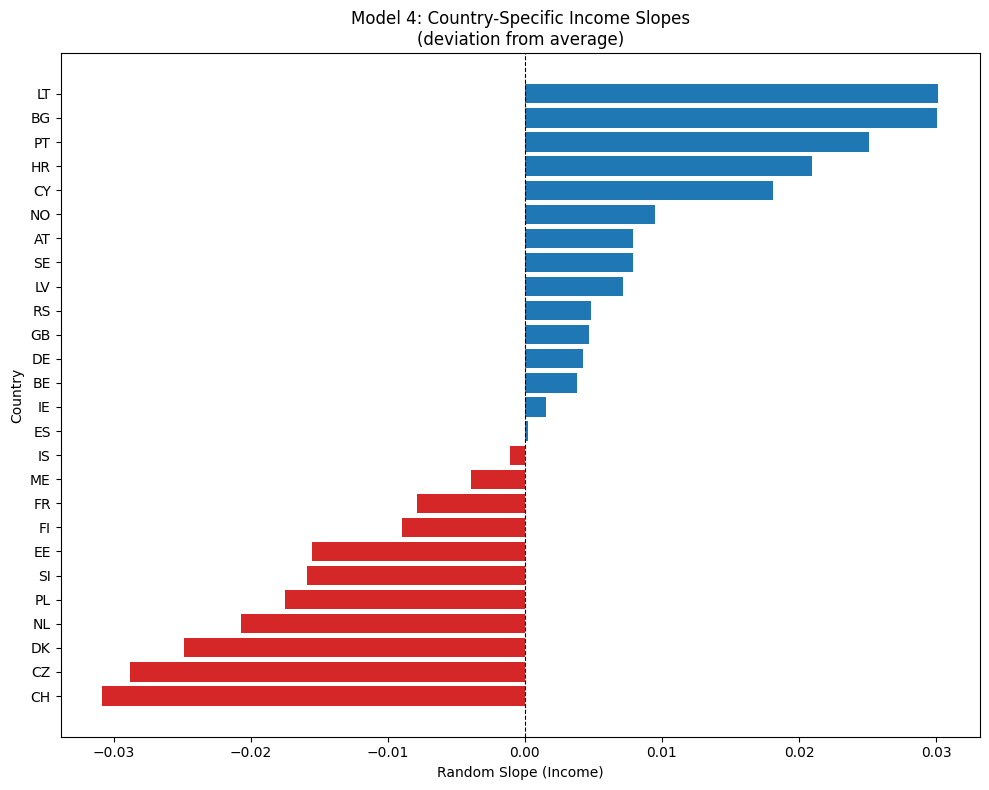

In [10]:
# Visualize random slopes for income by country
re_income = pd.DataFrame({
    country: {'intercept': vals['Group'], 'income_slope': vals.get('income_c', 0)}
    for country, vals in r4.random_effects.items()
}).T.sort_values('income_slope')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in re_income['income_slope']]
ax.barh(re_income.index, re_income['income_slope'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Random Slope (Income)')
ax.set_ylabel('Country')
ax.set_title('Model 4: Country-Specific Income Slopes\n(deviation from average)')
plt.tight_layout()
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PLOTS_DIR / '03_random_slopes_income.png', dpi=300, bbox_inches='tight')
plt.show()

## Model 5: Income x Gini Interaction

In [11]:
# Model 5: Cross-level interaction (income x Gini)
m5 = smf.mixedlm(f"redist_support ~ {full_formula} + income_c:gini_z",
                  data=df_model, groups=df_model["country"], re_formula="~income_c")
r5 = m5.fit(reml=True)
results['m5'] = r5

print(r5.summary())

# Extract interaction coefficient
interaction_coef = r5.fe_params.get('income_c:gini_z', None)
interaction_pval = r5.pvalues.get('income_c:gini_z', None)
if interaction_coef is not None:
    print(f"\nCross-level interaction (income x Gini):")
    print(f"  Coefficient: {interaction_coef:.4f}")
    print(f"  p-value: {interaction_pval:.4f}")
    print(f"  → {'Significant' if interaction_pval < 0.05 else 'Not significant'} at α = 0.05")

             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  redist_support
No. Observations:   31393    Method:              REML          
No. Groups:         26       Scale:               0.8493        
Min. group size:    468      Log-Likelihood:      -42095.8186   
Max. group size:    2006     Converged:           Yes           
Mean group size:    1207.4                                      
----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             3.859    0.046  83.746 0.000  3.768  3.949
income_c             -0.039    0.004 -10.265 0.000 -0.047 -0.032
education_c          -0.009    0.001  -6.566 0.000 -0.012 -0.006
age_c                 0.002    0.000   7.395 0.000  0.002  0.003
female                0.081    0.011   7.673 0.000  0.061  0.102
employed              0.024    0.013   

C:\Users\kaleb\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


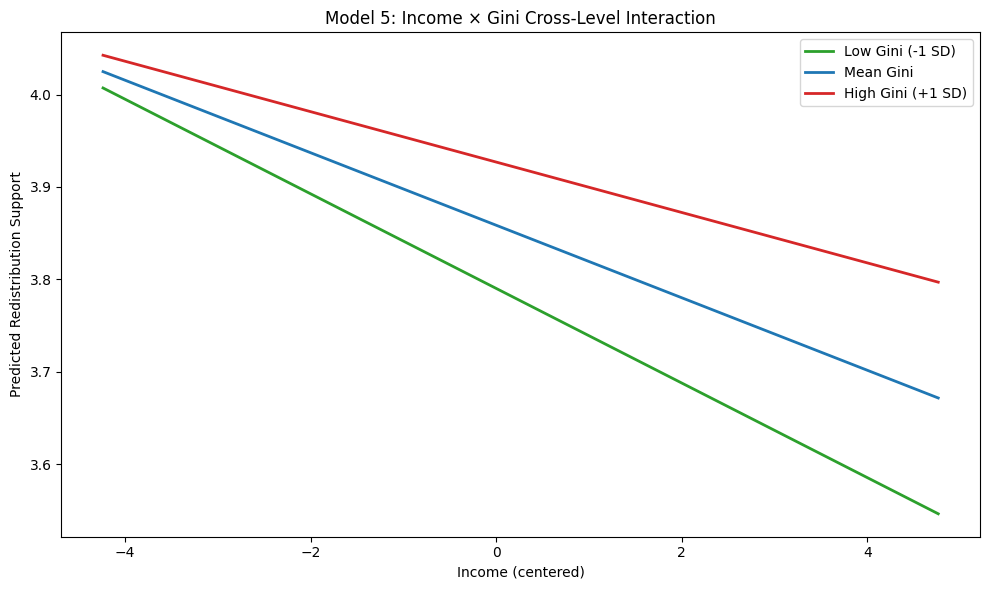

In [12]:
# Visualize interaction: income effect at different Gini levels
fig, ax = plt.subplots(figsize=(10, 6))

# Predict at low (-1 SD), mean (0), high (+1 SD) Gini
income_range = np.linspace(df_model['income_c'].min(), df_model['income_c'].max(), 100)
gini_levels = {'Low Gini (-1 SD)': -1, 'Mean Gini': 0, 'High Gini (+1 SD)': 1}
colors_interaction = ['#2ca02c', '#1f77b4', '#d62728']

intercept = r5.fe_params['Intercept']
b_income = r5.fe_params.get('income_c', 0)
b_gini = r5.fe_params.get('gini_z', 0)
b_interact = r5.fe_params.get('income_c:gini_z', 0)

for (label, gini_val), color in zip(gini_levels.items(), colors_interaction):
    y_pred = intercept + b_income * income_range + b_gini * gini_val + b_interact * income_range * gini_val
    ax.plot(income_range, y_pred, label=label, color=color, linewidth=2)

ax.set_xlabel('Income (centered)')
ax.set_ylabel('Predicted Redistribution Support')
ax.set_title('Model 5: Income × Gini Cross-Level Interaction')
ax.legend()
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '03_interaction_income_gini.png', dpi=300, bbox_inches='tight')
plt.show()

## Model 6: Random Slopes (Ideology)

In [13]:
# Model 6: Random slopes for ideology (intercept + ideology vary by country)
m6 = smf.mixedlm(f"redist_support ~ {full_formula}", data=df_model,
                  groups=df_model["country"], re_formula="~ideology_c")
r6 = m6.fit(reml=True)
results['m6'] = r6

print(r6.summary())
print(f"\nRandom effects covariance matrix:")
print(r6.cov_re)
print(f"\nInterpretation:")
print(f"  Ideology slope variance: {r6.cov_re.loc['ideology_c', 'ideology_c']:.4f}")
print(f"  → The ideology-redistribution relationship varies across countries")

              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   redist_support
No. Observations:   31393     Method:               REML          
No. Groups:         26        Scale:                0.8328        
Min. group size:    468       Log-Likelihood:       -41809.0287   
Max. group size:    2006      Converged:            Yes           
Mean group size:    1207.4                                        
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               3.849    0.049  78.762 0.000  3.753  3.945
income_c               -0.039    0.002 -18.047 0.000 -0.043 -0.034
education_c            -0.009    0.001  -6.809 0.000 -0.012 -0.007
age_c                   0.003    0.000   8.675 0.000  0.002  0.003
female                  0.078    0.011   7.375 0.000  0.057  0.098
employed  

C:\Users\kaleb\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


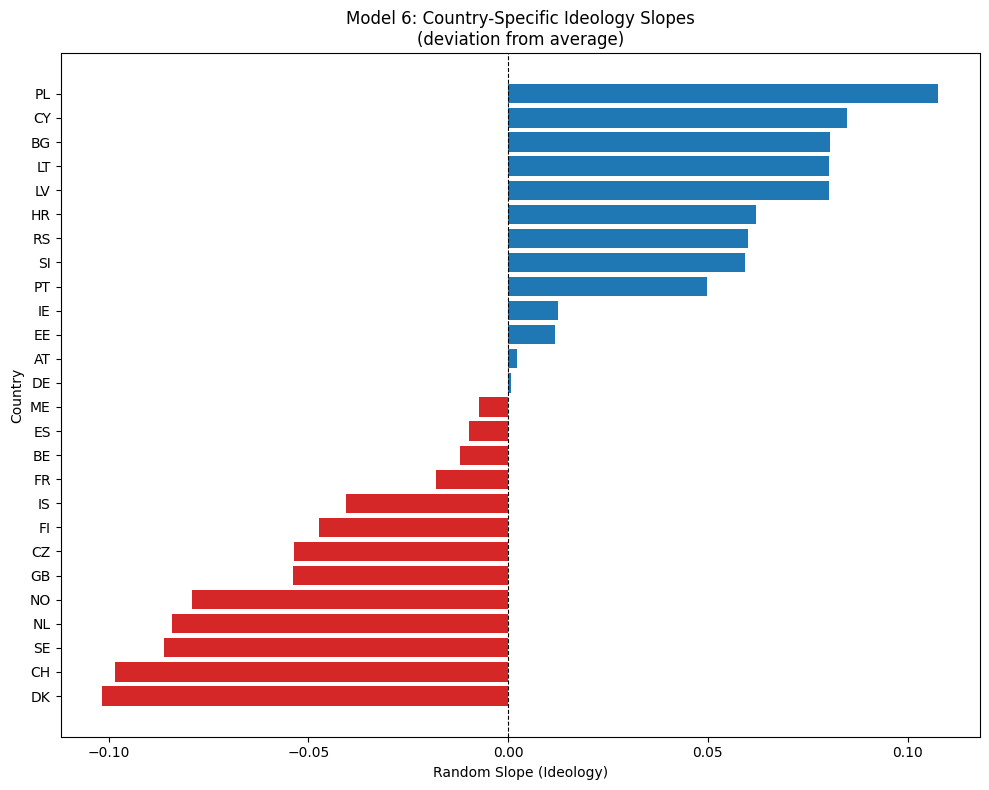

In [14]:
# Visualize random slopes for ideology by country
re_ideology = pd.DataFrame({
    country: {'intercept': vals['Group'], 'ideology_slope': vals.get('ideology_c', 0)}
    for country, vals in r6.random_effects.items()
}).T.sort_values('ideology_slope')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in re_ideology['ideology_slope']]
ax.barh(re_ideology.index, re_ideology['ideology_slope'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Random Slope (Ideology)')
ax.set_ylabel('Country')
ax.set_title('Model 6: Country-Specific Ideology Slopes\n(deviation from average)')
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '03_random_slopes_ideology.png', dpi=300, bbox_inches='tight')
plt.show()

## Model 7: Ideology x Gini Interaction

In [15]:
# Model 7: Cross-level interaction (ideology x Gini)
m7 = smf.mixedlm(f"redist_support ~ {full_formula} + ideology_c:gini_z",
                  data=df_model, groups=df_model["country"], re_formula="~ideology_c")
r7 = m7.fit(reml=True)
results['m7'] = r7

print(r7.summary())

# Extract interaction coefficient
interaction_coef = r7.fe_params.get('ideology_c:gini_z', None)
interaction_pval = r7.pvalues.get('ideology_c:gini_z', None)
if interaction_coef is not None:
    print(f"\nCross-level interaction (ideology x Gini):")
    print(f"  Coefficient: {interaction_coef:.4f}")
    print(f"  p-value: {interaction_pval:.4f}")
    print(f"  → {'Significant' if interaction_pval < 0.05 else 'Not significant'} at α = 0.05")

              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   redist_support
No. Observations:   31393     Method:               REML          
No. Groups:         26        Scale:                0.8328        
Min. group size:    468       Log-Likelihood:       -41810.1275   
Max. group size:    2006      Converged:            Yes           
Mean group size:    1207.4                                        
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               3.853    0.048  80.737 0.000  3.760  3.947
income_c               -0.039    0.002 -18.045 0.000 -0.043 -0.034
education_c            -0.009    0.001  -6.813 0.000 -0.012 -0.007
age_c                   0.003    0.000   8.673 0.000  0.002  0.003
female                  0.078    0.011   7.375 0.000  0.057  0.098
employed  

C:\Users\kaleb\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


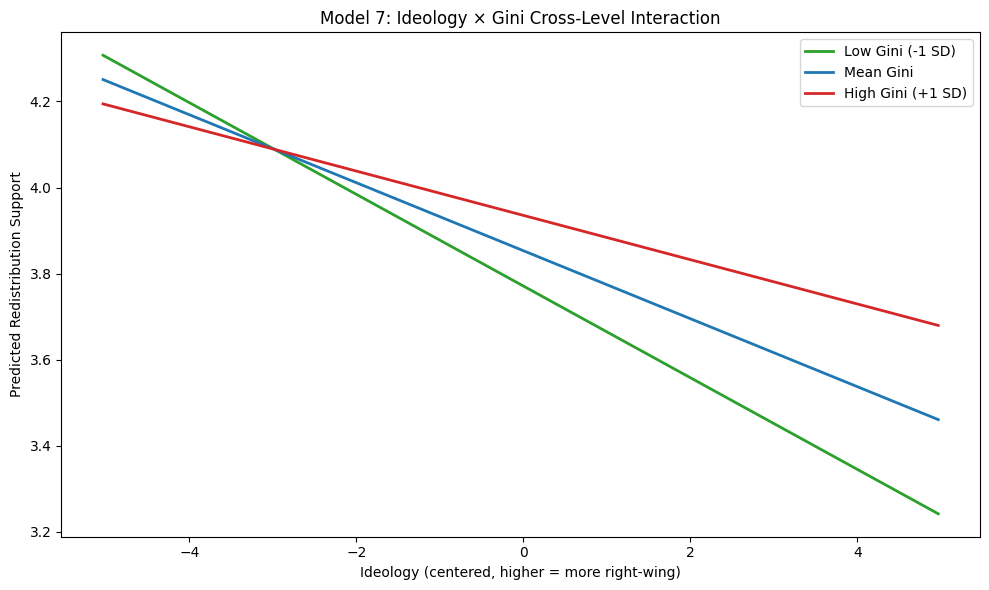

In [16]:
# Visualize interaction: ideology effect at different Gini levels
fig, ax = plt.subplots(figsize=(10, 6))

ideology_range = np.linspace(df_model['ideology_c'].min(), df_model['ideology_c'].max(), 100)
gini_levels = {'Low Gini (-1 SD)': -1, 'Mean Gini': 0, 'High Gini (+1 SD)': 1}
colors_interaction = ['#2ca02c', '#1f77b4', '#d62728']

intercept = r7.fe_params['Intercept']
b_ideology = r7.fe_params.get('ideology_c', 0)
b_gini = r7.fe_params.get('gini_z', 0)
b_interact = r7.fe_params.get('ideology_c:gini_z', 0)

for (label, gini_val), color in zip(gini_levels.items(), colors_interaction):
    y_pred = intercept + b_ideology * ideology_range + b_gini * gini_val + b_interact * ideology_range * gini_val
    ax.plot(ideology_range, y_pred, label=label, color=color, linewidth=2)

ax.set_xlabel('Ideology (centered, higher = more right-wing)')
ax.set_ylabel('Predicted Redistribution Support')
ax.set_title('Model 7: Ideology × Gini Cross-Level Interaction')
ax.legend()
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '03_interaction_ideology_gini.png', dpi=300, bbox_inches='tight')
plt.show()

## Model Comparison Table

In [17]:
# Build coefficient comparison table across all 7 models
model_names = ['M1: Null', 'M2: L1', 'M3: L1+L2', 'M4: RS Income',
               'M5: Income×Gini', 'M6: RS Ideology', 'M7: Ideology×Gini']
all_results = [r1, r2, r3, r4, r5, r6, r7]

# Collect fixed effects
all_params = set()
for r in all_results:
    all_params.update(r.fe_params.index)

# Build table
rows = []
for param in sorted(all_params):
    row = {'Variable': param}
    for name, r in zip(model_names, all_results):
        if param in r.fe_params.index:
            coef = r.fe_params[param]
            pval = r.pvalues[param]
            stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            row[name] = f"{coef:.3f}{stars}"
        else:
            row[name] = ''
    rows.append(row)

coef_table = pd.DataFrame(rows).set_index('Variable')

print("Fixed Effects Comparison Table:")
print("="*100)
print(coef_table.to_string())
print("\nSignificance: * p<0.05, ** p<0.01, *** p<0.001")

# Save
config.TABLES_DIR.mkdir(parents=True, exist_ok=True)
coef_table.to_csv(config.TABLES_DIR / '03_coefficient_table.csv')
print(f"\nSaved to: {config.TABLES_DIR / '03_coefficient_table.csv'}")

Fixed Effects Comparison Table:
                     M1: Null     M2: L1  M3: L1+L2 M4: RS Income M5: Income×Gini M6: RS Ideology M7: Ideology×Gini
Variable                                                                                                           
Intercept            3.896***   3.848***   3.852***      3.853***        3.859***        3.849***          3.853***
age_c                           0.002***   0.002***      0.002***        0.002***        0.003***          0.003***
education_c                    -0.009***  -0.009***     -0.009***       -0.009***       -0.009***         -0.009***
employed                           0.024      0.024         0.024           0.024          0.026*            0.026*
female                          0.082***   0.082***      0.082***        0.081***        0.078***          0.078***
gdp_per_capita_z                             -0.051        -0.040          -0.040           0.044             0.043
gini_z                                  

## Model Fit Statistics

Model Fit Statistics:
                   AIC  BIC  Log-Likelihood      N  Groups  Resid. Var  Intercept Var
Model                                                                                
M1: Null           NaN  NaN      -43436.914  31393      26       0.928          0.077
M2: L1             NaN  NaN      -42121.100  31393      26       0.852          0.058
M3: L1+L2          NaN  NaN      -42124.495  31393      26       0.852          0.052
M4: RS Income      NaN  NaN      -42095.520  31393      26       0.849          0.055
M5: Income×Gini    NaN  NaN      -42095.819  31393      26       0.849          0.052
M6: RS Ideology    NaN  NaN      -41809.029  31393      26       0.833          0.059
M7: Ideology×Gini  NaN  NaN      -41810.128  31393      26       0.833          0.056

Note: Lower AIC/BIC = better fit
Saved to: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis\outputs\tables\03_fit_statistics.csv


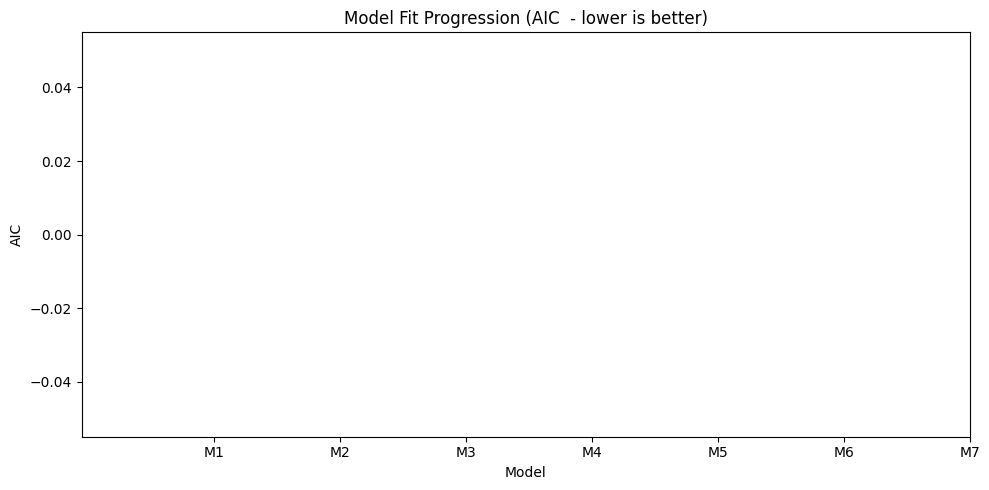

In [18]:
# Model fit comparison
fit_rows = []
for name, r in zip(model_names, all_results):
    fit_rows.append(model_fit_stats(r, name))

fit_df = pd.DataFrame(fit_rows).set_index('Model')

print("Model Fit Statistics:")
print("="*90)
print(fit_df.to_string())
print("\nNote: Lower AIC/BIC = better fit")

# Save
fit_df.to_csv(config.TABLES_DIR / '03_fit_statistics.csv')
print(f"Saved to: {config.TABLES_DIR / '03_fit_statistics.csv'}")

# Visualize AIC progression
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 8), fit_df['AIC'].values, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xticks(range(1, 8))
ax.set_xticklabels([f'M{i}' for i in range(1, 8)])
ax.set_xlabel('Model')
ax.set_ylabel('AIC')
ax.set_title('Model Fit Progression (AIC  - lower is better)')
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '03_model_fit_aic.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

The 7-model sequence confirms that redistribution preferences cluster meaningfully across countries (ICC = 7.7%) and that individual self-interest, ideology, and meritocratic beliefs are the strongest predictors. Country-level economic conditions (Gini, GDP, unemployment) are not significant as main effects but explain 10% of between-country variance. The income x Gini interaction (p = 0.002) is the key nonlinearity: higher inequality weakens the negative income effect, meaning the rich in unequal countries are relatively less opposed to redistribution. The ideology x Gini interaction (p = 0.024) shows a parallel pattern. These cross-level interactions parameterize the agent-based simulation.

In [19]:
print("Done.")

Done.
